# !DataSet:
https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

In [49]:
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [50]:
# Load the data
data_path = Path('./dataset/loan_approval_dataset.csv')

print("data_path.exists(): ",data_path.exists())  # Check if the file exists
#print(data_path.is_file())  # Check if the file exists
#print(data_path.is_dir() )  # Check if the file exists
#print(data_path)  # Print the path to the file
df = pd.read_csv(data_path)
df.head()  # Display the first few rows of the DataFrame

data_path.exists():  True


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [51]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [52]:
# Fix space issue in column names
df.columns = df.columns.str.strip()

In [53]:
df.columns.to_list()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [54]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [55]:
df['loan_status'] = df['loan_status'].str.strip()
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [56]:
approved_df = df[df['loan_status'] == 'Approved'].copy()
approved_df.shape

(2656, 13)

In [57]:
reg_target = "loan_amount"
reg_df = approved_df = approved_df.dropna(subset=[reg_target]).copy()
reg_df.shape

(2656, 13)

In [58]:
X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]
X_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2656 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   2656 non-null   int64 
 1   no_of_dependents          2656 non-null   int64 
 2   education                 2656 non-null   object
 3   self_employed             2656 non-null   object
 4   income_annum              2656 non-null   int64 
 5   loan_term                 2656 non-null   int64 
 6   cibil_score               2656 non-null   int64 
 7   residential_assets_value  2656 non-null   int64 
 8   commercial_assets_value   2656 non-null   int64 
 9   luxury_assets_value       2656 non-null   int64 
 10  bank_asset_value          2656 non-null   int64 
 11  loan_status               2656 non-null   object
dtypes: int64(9), object(3)
memory usage: 269.8+ KB


In [59]:
cat_cols_reg = X_reg.select_dtypes(include=['object','category']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()

In [60]:
print("Categorical columns: ", cat_cols_reg)
print("Numerical columns: ", num_cols_reg)

Categorical columns:  ['education', 'self_employed', 'loan_status']
Numerical columns:  ['loan_id', 'no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [61]:
from sklearn.model_selection import train_test_split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=10)

print("Train Size :", Xr_train.shape)
print("Test Size :", Xr_test.shape)

Train Size : (2124, 12)
Test Size : (532, 12)


In [62]:
from seaborn import categorical
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])




In [63]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
],remainder='drop')

# FIT RF_Reg baseline Model

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor())
])

In [66]:
param_reg_grid = {
    'rf_reg__n_estimators': [100, 200, 300, 400],
    'rf_reg__max_depth': [None, 4, 8, 10],
    'rf_reg__max_features': ['sqrt', None],
    'rf_reg__min_samples_split': [2, 5, 10]
    }

In [ ]:
from sklearn.model_selection import GridSearchCV


grid = GridSearchCV(rf_reg_pipeline, param_reg_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(Xr_train, yr_train)

In [ ]:
print("Best Parameters(rf_reg): ", grid.best_params_)
best_reg = grid.best_estimator_

Best Parameters(rf_reg):  {'rf_reg__max_depth': 8, 'rf_reg__max_features': None, 'rf_reg__min_samples_split': 5, 'rf_reg__n_estimators': 400}


In [ ]:
grid.best_score_

np.float64(0.8706313329682487)

# regression Validation

In [ ]:
# Best Parameters(rf_reg):  {'rf_reg__max_depth': 8, 'rf_reg__max_features': None, 'rf_reg__min_samples_split': 5, 'rf_reg__n_estimators': 400}


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor(
        max_depth=8,
        max_features=None,
        min_samples_split=5,
        n_estimators=400,
        random_state=10
    ))
])

rf_reg_pipeline.fit(Xr_train, yr_train)
yr_test_pred = rf_reg_pipeline.predict(Xr_test)

print("R2 Score: ", r2_score(yr_test, yr_test_pred))
print("MAE: ", mean_absolute_error(yr_test, yr_test_pred))
print("MSE: ", mean_squared_error(yr_test, yr_test_pred))



R2 Score:  0.8653581743504712
MAE:  2512738.312737301
MSE:  11115837008508.271


# Checking feature importance

In [ ]:
feature_importance = rf_reg_pipeline.named_steps['rf_reg'].feature_importances_
feature_importance

array([8.22851632e-03, 3.29291860e-03, 9.31722024e-01, 5.23811432e-03,
       1.30937115e-02, 9.95289778e-03, 8.93991007e-03, 1.00813871e-02,
       7.98480682e-03, 3.26176924e-04, 3.52548698e-04, 4.02963645e-04,
       3.84023854e-04, 0.00000000e+00])

feature_names: ['num__loan_id' 'num__no_of_dependents' 'num__income_annum'
 'num__loan_term' 'num__cibil_score' 'num__residential_assets_value'
 'num__commercial_assets_value' 'num__luxury_assets_value'
 'num__bank_asset_value' 'cat__education_ Graduate'
 'cat__education_ Not Graduate' 'cat__self_employed_ No'
 'cat__self_employed_ Yes' 'cat__loan_status_Approved']
Top 10 Important Feautures : 
                           Feature  Importance
2               num__income_annum    0.931722
4                num__cibil_score    0.013094
7        num__luxury_assets_value    0.010081
5   num__residential_assets_value    0.009953
6    num__commercial_assets_value    0.008940
0                    num__loan_id    0.008229
8           num__bank_asset_value    0.007985
3                  num__loan_term    0.005238
1           num__no_of_dependents    0.003293
11         cat__self_employed_ No    0.000403


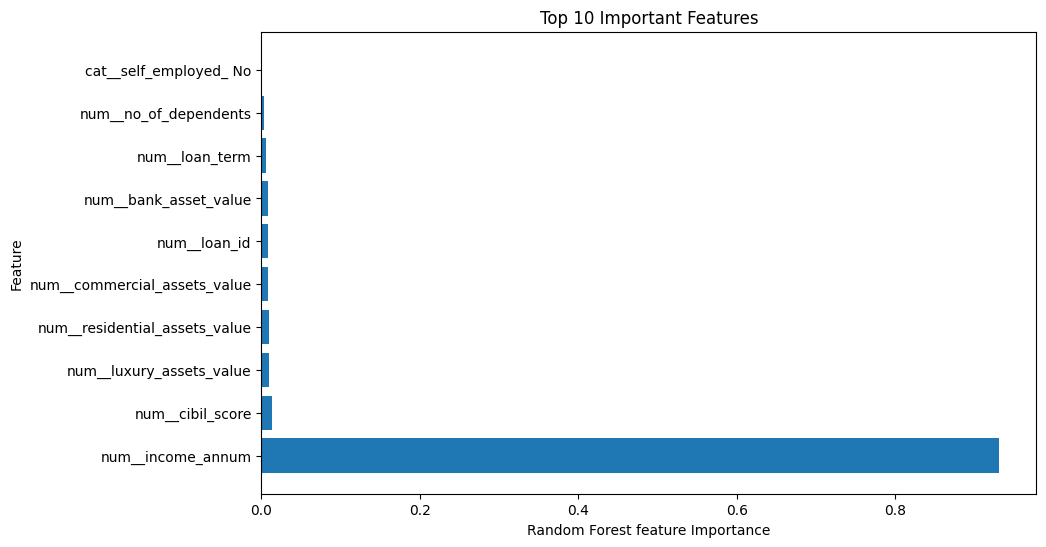

In [ ]:
preprocessor = rf_reg_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()
print('feature_names:',feature_names)

importance_df =  pd.DataFrame(
    {
        'Feature' : feature_names,
        'Importance' : feature_importance
    }
)

importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Top 10 Important Feautures : \n", importance_df.head(10))

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Random Forest feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')
plt.show()

In [ ]:
# Integrate the Staege 1 and Stage 2 models to predict loan amount for the test set of Stage 1 and evaluate the performance.

In [ ]:
import joblib

In [ ]:
joblib.dump(rf_reg_pipeline, 'stage_2_rf_regression_pipeline.pkl')

['stage_2_rf_regression_pipeline.pkl']

# Prediction Function

In [ ]:
classification_model_path = 'stage_1_rf_classification_pipeline.pkl'
regression_model_path = 'stage_2_rf_regression_pipeline.pkl'

classification_pipeline = joblib.load("./stage_1_rf_classification_pipeline.pkl")
regression_pipeline = joblib.load("./stage_2_rf_regression_pipeline.pkl")

In [ ]:
def two_stage_predict(applicant_df):
    """
    Two-stage loan prediction: Classification (approval) -> Regression (amount)
    
    Parameters:
    applicant_df: Row(s) with ORIGINAL features including loan_amount
                  (as used in Stage 1 classification training)
    
    Returns:
    Dictionary with 'loan_status' (0/1) and optionally 'regression_prediction' (loan amount)
    """
    out = {}
    
    # Stage 1: Predict loan approval (classification_pipeline expects loan_amount as a feature)
    approve = classification_pipeline.predict(applicant_df)[0]
    approval_label = "Approved" if approve == 1 else "Rejected"
    print(f"Predicted Approval: {approval_label} ({approve})")
    out['loan_status'] = int(approve)
    
    if approve == 1:
        # Stage 2: Predict loan amount only for approved loans
        print("Predicting loan amount for approved application...")
        applicant_df_stage2 = applicant_df.copy()
        applicant_df_stage2['loan_status'] = 'Approved'
        
        # Drop loan_amount for regression (it's only needed as a training feature in Stage 1)
        applicant_df_stage2_features = applicant_df_stage2.drop(columns=['loan_amount'], errors='ignore')
        
        loan_amount_pred = regression_pipeline.predict(applicant_df_stage2_features)[0]
        print(f"Predicted Loan Amount: ${loan_amount_pred:,.2f}")
        out['regression_prediction'] = float(loan_amount_pred)
        
    else:
        print("Loan application rejected - loan amount prediction skipped.")
    
    return out

In [ ]:
regression_pipeline.feature_names_in_

array(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype=object)

In [ ]:
# Get a test example from the original data (before loan_amount was dropped)
# This matches what the classification_pipeline expects
from sklearn.model_selection import train_test_split

# Reload original data and prepare for classification pipeline (includes loan_amount)
df_original = pd.read_csv('./dataset/loan_approval_dataset.csv')
df_original.columns = df_original.columns.str.strip()
df_original['loan_status'] = df_original['loan_status'].str.strip()
df_clf = df_original.dropna(subset=['loan_status']).copy()
df_clf = df_clf.drop(columns=['loan_id'], errors='ignore')

X_original = df_clf.drop(columns=['loan_status'])
y_original = df_clf['loan_status'].copy()

# Create the same test set as Stage 1
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_original, y_original, test_size=0.2, random_state=10, stratify=y_original
)

# Get example row for two-stage prediction (includes loan_amount as required by classification pipeline)
example_row = X_test_clf.iloc[[0]]
print("Example row for prediction (includes loan_amount): \n")
display(example_row)

Example row for prediction: 



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3656,3657,1,Not Graduate,No,4400000,4,884,9800000,6500000,15000000,6000000,Approved


In [ ]:
two_stage_predict(example_row)

ValueError: columns are missing: {'loan_amount'}